In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load cleaned data
df = pd.read_csv('../data/cleaned/cleaned_job_postings.csv')

print(f"Data loaded! {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded! 12,217 rows x 13 columns


In [3]:
# ---- SKILL CLUSTERING ----
# We group individual skills into broader categories
# This shows which TYPE of skill is most in demand

skill_clusters = {
    'Cloud Platforms': ['AWS', 'Azure', 'GCP', 'Snowflake', 'Databricks'],
    'Programming': ['Python', 'SQL', 'R', 'Java', 'Scala'],
    'ML and AI': ['Machine Learning', 'Deep Learning', 'NLP', 'AI', 'MLOps'],
    'BI and Visualization': ['Power BI', 'Tableau', 'Looker', 'Qlik'],
    'Data Engineering': ['Spark', 'Hadoop', 'Kafka', 'Airflow', 'ETL', 'dbt'],
    'Databases': ['Oracle', 'MySQL', 'PostgreSQL', 'MongoDB'],
    'Other Tools': ['Excel', 'Statistics', 'Analytics', 'DevOps']
}

# Count how many job titles mention each cluster
cluster_counts = {}
for cluster, skills in skill_clusters.items():
    total = 0
    for skill in skills:
        pattern = r'\b' + re.escape(skill) + r'\b'
        count = df['job_title'].str.contains(pattern, case=False, na=False).sum()
        total += count
    cluster_counts[cluster] = total

# Convert to DataFrame
cluster_df = pd.DataFrame(
    list(cluster_counts.items()),
    columns=['Skill Category', 'Job Count']
).sort_values('Job Count', ascending=False)

print("Skill clusters:")
print(cluster_df.to_string(index=False))

Skill clusters:
      Skill Category  Job Count
           ML and AI       1243
         Other Tools        476
         Programming        375
     Cloud Platforms        337
    Data Engineering        105
           Databases         66
BI and Visualization         48


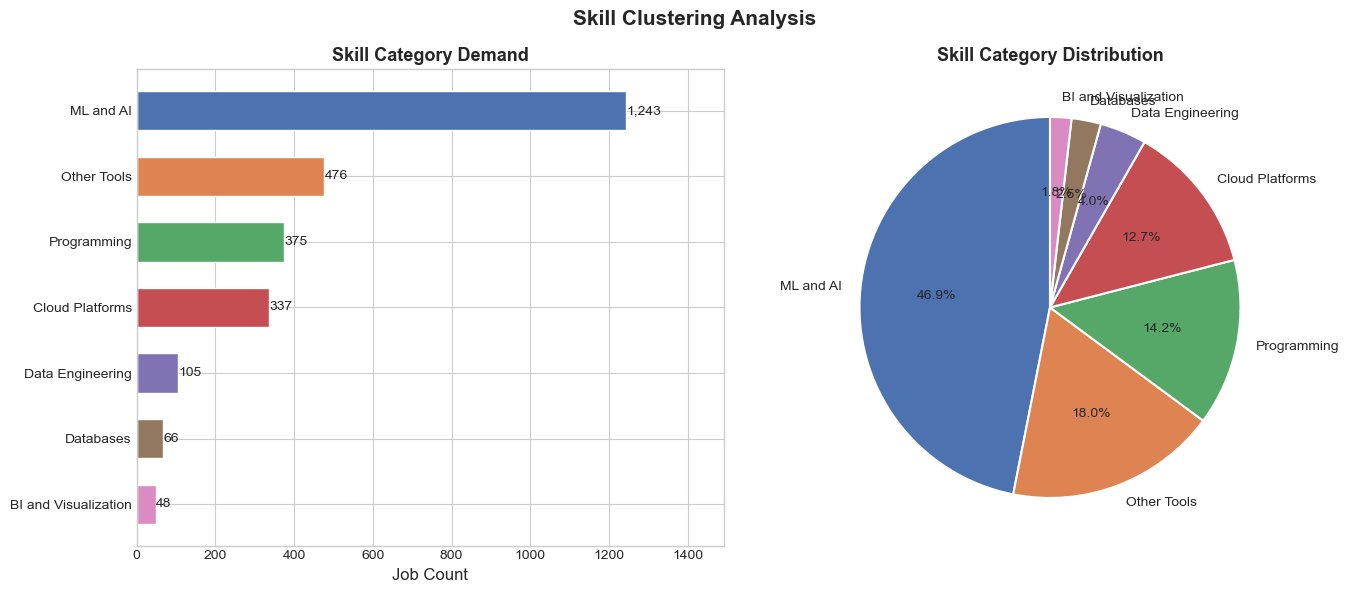

Chart saved!


In [4]:
# ---- CHART: Skill Category Demand ----

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
          '#8172B3', '#937860', '#DA8BC3']

axes[0].barh(
    cluster_df['Skill Category'][::-1],
    cluster_df['Job Count'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)
for i, (val, name) in enumerate(zip(
    cluster_df['Job Count'][::-1],
    cluster_df['Skill Category'][::-1]
)):
    axes[0].text(val + 1, i, f'{val:,}', va='center', fontsize=10)

axes[0].set_xlabel('Job Count', fontsize=12)
axes[0].set_title('Skill Category Demand', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, cluster_df['Job Count'].max() * 1.2)

# Pie chart
axes[1].pie(
    cluster_df['Job Count'],
    labels=cluster_df['Skill Category'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Skill Category Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Skill Clustering Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/11_skill_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [5]:
# ---- JOB CATEGORY ANALYSIS ----
# Group job titles into broader categories

def categorize_job(title):
    title = str(title).lower()
    if any(x in title for x in ['machine learning', 'ml', 'ai', 'deep learning', 'nlp']):
        return 'ML and AI'
    elif any(x in title for x in ['data engineer', 'etl', 'pipeline', 'warehouse']):
        return 'Data Engineering'
    elif any(x in title for x in ['data analyst', 'analytics', 'business analyst']):
        return 'Data Analytics'
    elif any(x in title for x in ['data scientist', 'scientist']):
        return 'Data Science'
    elif any(x in title for x in ['architect', 'architecture']):
        return 'Data Architecture'
    elif any(x in title for x in ['manager', 'director', 'lead', 'head']):
        return 'Management'
    else:
        return 'Other'

df['job_category'] = df['job_title'].apply(categorize_job)

print("Job categories:")
print(df['job_category'].value_counts())

Job categories:
Other                3001
ML and AI            2506
Data Analytics       2276
Data Engineering     1777
Management           1384
Data Science          756
Data Architecture     517
Name: job_category, dtype: int64


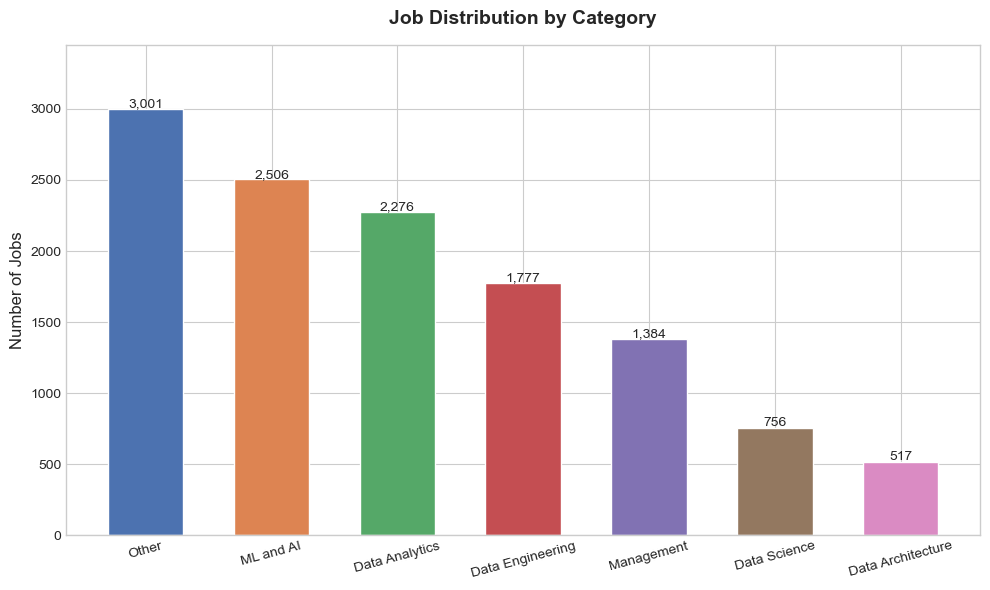

Chart saved!


In [6]:
# ---- CHART: Job Category Distribution ----

cat_counts = df['job_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4C72B0', '#DD8452', '#55A868',
          '#C44E52', '#8172B3', '#937860', '#DA8BC3']

bars = ax.bar(
    cat_counts.index,
    cat_counts.values,
    color=colors,
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, cat_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{val:,}',
        ha='center', fontsize=10
    )

ax.set_ylabel('Number of Jobs', fontsize=12)
ax.set_title('Job Distribution by Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, cat_counts.max() * 1.15)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../outputs/charts/12_job_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [7]:
# ---- COMPANY TYPE ANALYSIS ----
# Identify recruitment agencies vs real employers

# Known recruitment agencies in the dataset
agencies = [
    'Jobs For Humanity', 'Recruiting From Scratch',
    'Dice', 'Clearancejobs', 'Clickjobs.Io',
    'Energy Jobline'
]

def company_type(company):
    if any(agency.lower() in str(company).lower() for agency in agencies):
        return 'Recruitment Agency'
    else:
        return 'Direct Employer'

df['company_type'] = df['company'].apply(company_type)

# Count
type_counts = df['company_type'].value_counts()
print("Company type breakdown:")
print(type_counts)
print(f"\nDirect employer jobs: {type_counts.get('Direct Employer', 0):,}")
print(f"Agency jobs: {type_counts.get('Recruitment Agency', 0):,}")

Company type breakdown:
Direct Employer       10511
Recruitment Agency     1706
Name: company_type, dtype: int64

Direct employer jobs: 10,511
Agency jobs: 1,706


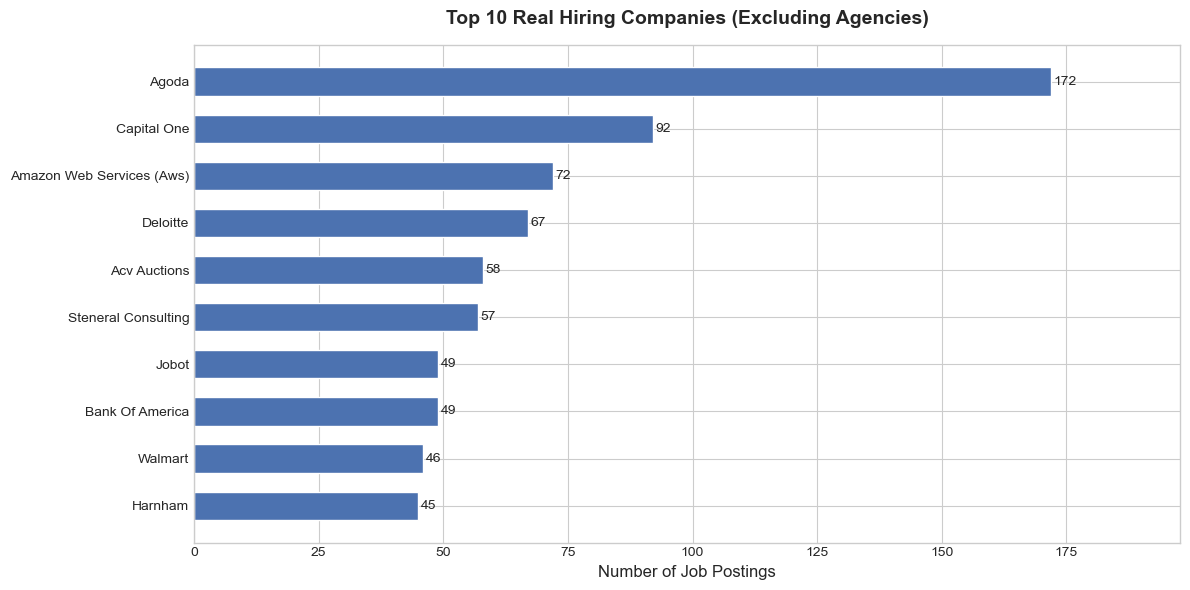

Chart saved!


In [8]:
# ---- TOP REAL EMPLOYERS ----
# Filter out agencies and show real hiring companies

real_employers = df[df['company_type'] == 'Direct Employer']
top_real = real_employers['company'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_real.index[::-1],
    top_real.values[::-1],
    color='#4C72B0',
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, top_real.values[::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center', fontsize=10
    )

ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.set_title('Top 10 Real Hiring Companies (Excluding Agencies)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_real.max() * 1.15)

plt.tight_layout()
plt.savefig('../outputs/charts/13_top_real_employers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
# Save updated dataframe with new columns
df.to_csv('../data/cleaned/cleaned_job_postings.csv', index=False)
print("Updated dataset saved with new columns:")
print(f"  job_category — {df['job_category'].nunique()} categories")
print(f"  company_type — {df['company_type'].nunique()} types")

Updated dataset saved with new columns:
  job_category — 7 categories
  company_type — 2 types


In [10]:
# ---- PHASE 7 SUMMARY ----

print("=" * 45)
print("PHASE 7 — ADVANCED ANALYTICS SUMMARY")
print("=" * 45)

print("\n1. SKILL CLUSTERS:")
print(cluster_df.to_string(index=False))

print("\n2. JOB CATEGORIES:")
print(df['job_category'].value_counts().to_string())

print("\n3. COMPANY TYPES:")
print(df['company_type'].value_counts().to_string())

print("\n4. TOP REAL EMPLOYERS:")
print(real_employers['company'].value_counts().head(5).to_string())

PHASE 7 — ADVANCED ANALYTICS SUMMARY

1. SKILL CLUSTERS:
      Skill Category  Job Count
           ML and AI       1243
         Other Tools        476
         Programming        375
     Cloud Platforms        337
    Data Engineering        105
           Databases         66
BI and Visualization         48

2. JOB CATEGORIES:
Other                3001
ML and AI            2506
Data Analytics       2276
Data Engineering     1777
Management           1384
Data Science          756
Data Architecture     517

3. COMPANY TYPES:
Direct Employer       10511
Recruitment Agency     1706

4. TOP REAL EMPLOYERS:
Agoda                        172
Capital One                   92
Amazon Web Services (Aws)     72
Deloitte                      67
Acv Auctions                  58


In [11]:
import os

files = sorted(os.listdir('../outputs/charts/'))
print(f"Total charts saved: {len(files)}")
for f in files:
    print(f"  {f}")

Total charts saved: 17
  01_top_job_titles.png
  02_top_locations.png
  03_top_companies.png
  04_job_levels.png
  05_job_types.png
  06_jobs_by_country.png
  07_top_skills.png
  08_jobs_by_date.png
  08_skills_by_level.png
  09_jobs_by_date.png
  09_top_us_cities.png
  10_top_us_cities.png
  11_skill_clusters.png
  12_job_categories.png
  13_top_real_employers.png
  dashboard_screenshot.png
  dashboard_screenshot.png.png
